In [132]:
import sys,os
sys.path.append(r'X:/Strategies/LeadLagXGB/')
sys.path.append(r'Z:/EnergyTrading/Python/')
sys.path.append(r'Z:/EnergyTrading/Python/Strategies/LeadLagXGB/')

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.DB_reader import Database
from datetime import date, timedelta

In [134]:
#importing custom library
!pip install git+https://github.com/Vrboska/mofr@master

  Cloning https://github.com/Vrboska/mofr (to revision master) to c:\users\andrej\appdata\local\temp\pip-req-build-wkfl4328
  Resolved https://github.com/Vrboska/mofr to commit 3509aedad3ad1469ec00fecd358b78860d8afb6f
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/Vrboska/mofr 'C:\Users\andrej\AppData\Local\Temp\pip-req-build-wkfl4328'
  Running command git checkout -b master --track origin/master
  branch 'master' set up to track 'origin/master'.
  Switched to a new branch 'master'


In [135]:
import mofr

# Data Loading

In [136]:
import pickle
### LOAD DATA ###
dump_path = 's:\Algo\Database\Model Data\model_data_03_06.pkl'
with open(dump_path, 'rb') as f:
    loaded_data = pickle.load(f)

df = loaded_data['df_data']

In [137]:
start_time = time(9, 0, 0)
end_time = time(17, 0, 0)

df = df.between_time(start_time, end_time).reset_index().rename(columns={'index':'datetime'})

In [138]:
df.head()

,datetime,class_70_4,class_70_6,class_70_10,class_100_10,class_150_10,delta_a_05,delta_a_10,delta_a_50,delta_a_75,delta_b_05,delta_b_10,delta_b_50,delta_b_75,delta_mid_05,delta_mid_10,delta_mid_50,delta_mid_75,delta_ba_05,delta_ba_10,delta_ba_50,delta_ba_75,ba_volrat_00,ba_volrat_05,ba_volrat_08,ba_volrat_10,ba_volrat_15,ba_volrat_20,ba_volrat_25,diff_am_wm_00,diff_am_wm_05,diff_am_wm_08,diff_am_wm_10,diff_am_wm_15,diff_am_wm_20,diff_am_wm_25,delta_mw_00_05,delta_mw_05_05,delta_mw_08_05,delta_mw_10_05,delta_mw_15_05,delta_mw_20_05,delta_mw_25_05,delta_mw_00_10,delta_mw_05_10,delta_mw_08_10,delta_mw_10_10,delta_mw_15_10,delta_mw_20_10,delta_mw_25_10,delta_mw_00_50,delta_mw_05_50,delta_mw_08_50,delta_mw_10_50,delta_mw_15_50,delta_mw_20_50,delta_mw_25_50,delta_mw_00_75,delta_mw_05_75,delta_mw_08_75,delta_mw_10_75,delta_mw_15_75,delta_mw_20_75,delta_mw_25_75,b_price_sparsity,a_price_sparsity,b_price,a_price,ba_spread,diff_ema_am_wm_00,diff_ema_am_wm_05,diff_ema_am_wm_08,diff_ema_am_wm_10,diff_ema_am_wm_15,diff_ema_am_wm_20,diff_ema_am_wm_25,diff_ema_ba_mba,lamb_tr_b_05,lamb_tr_a_05,lamb_tr_b_10,lamb_tr_a_10,lamb_tr_b_50,lamb_tr_a_50,lamb_tr_b_75,lamb_tr_a_75,ilamb_b_10,ilamb_a_10,ilamb_b_50,ilamb_a_50,ilamb_b_75,ilamb_a_75,dlamb_b_75,dlamb_a_75,trd_momentum_10,trd_momentum_acc_10,trd_momentum_50,trd_momentum_acc_50,trd_momentum_100,trd_momentum_acc_100,ret,vpin_10,vpin_20,vpin_50,vpin_100,dti_300s,trd_gap
0,2025-03-17 09:00:56.014312273,0.0,0.0,0.0,0.0,0.0,1.923456,0.931445,0.160886,0.105523,1.922151,0.930802,0.160772,0.105448,1.922804,0.931124,0.160829,0.105486,0.098383,0.048481,0.008629,0.005678,0.277778,0.392857,0.263889,0.250000,0.023810,-0.088889,0.075763,0.000442,0.000652,0.000424,3.827067e-04,-2.545535e-04,-0.000675,0.000211,1.922717,1.922643,1.922673,1.922717,1.922878,1.922974,1.922739,0.931070,0.931031,0.931054,0.931072,0.931164,0.931220,0.931089,0.160816,0.160809,0.160815,0.160817,0.160837,0.160850,0.160822,0.105477,0.105472,0.105476,0.105478,0.105491,0.105500,0.105481,0.166667,0.173333,75.26,75.498333,0.238333,-0.000392,-0.000325,-0.000012,-0.000248,0.000046,0.000314,-0.000009,0.059120,0.2,0.8,0.2,0.8,0.46,0.54,0.506667,0.493333,False,False,False,False,False,False,0.009078,0.036312,0.769963,0.161702,0.153327,0.004664,0.076580,0.001532,NaN,NaN,NaN,NaN,NaN,NaN,0.09
1,2025-03-17 09:00:56.014360655,0.0,0.0,0.0,0.0,0.0,1.923456,0.931445,0.160886,0.105523,1.922151,0.930802,0.160772,0.105448,1.922804,0.931124,0.160829,0.105486,0.098383,0.048481,0.008629,0.005678,0.277778,0.392857,0.263889,0.250000,0.023810,-0.088889,0.075763,0.000442,0.000652,0.000424,3.827067e-04,-2.545535e-04,-0.000675,0.000211,1.922717,1.922643,1.922673,1.922717,1.922878,1.922974,1.922739,0.931070,0.931031,0.931054,0.931072,0.931164,0.931220,0.931089,0.160816,0.160809,0.160815,0.160817,0.160837,0.160850,0.160822,0.105477,0.105472,0.105476,0.105478,0.105491,0.105500,0.105481,0.166667,0.173333,75.26,75.498333,0.238333,-0.000392,-0.000325,-0.000012,-0.000248,0.000046,0.000314,-0.000009,0.059120,0.2,0.8,0.2,0.8,0.46,0.54,0.506667,0.493333,False,False,False,False,False,False,0.009227,0.036908,0.931394,-0.358907,0.160877,-0.099946,0.078482,-0.037264,NaN,NaN,NaN,NaN,NaN,0.000000,0.09
2,2025-03-17 09:00:56.027458802,0.0,0.0,0.0,0.0,0.0,1.988307,1.054201,0.168344,0.108861,1.987028,1.053475,0.168218,0.108778,1.987668,1.053838,0.168281,0.108820,0.096412,0.054662,0.009507,0.006204,-0.222222,0.216931,0.216931,0.031746,0.031746,0.031746,-0.027778,-0.000206,0.000347,0.000347,-5.373039e-05,-5.373039e-05,-0.000054,-0.000183,1.987414,1.987166,1.987364,1.987437,1.987814,1.988085,1.987627,1.053653,1.053513,1.053651,1.053677,1.053934,1.054120,1.053804,0.168235,0.168207,0.168241,0.168242,0.168302,0.168346,0.168272,0.108789,0.108770,0.108793,0.108794,0.108834,0.108863,0.108814,0.160000,0.210000,75.26,75.400000,0.140000,-0.000385,-0.000314,-0.000007,-0.000242,0.000044,0.000305,-0.000008,-0.039344,0.2,0.8,0.2,0.8,0.46,0.54,0.506667,0.493333,False,False,False,False,False,False,0.009

In [139]:
df.shape

(42388, 106)

In [140]:
df.columns

Index(['datetime', 'class_70_4', 'class_70_6', 'class_70_10', 'class_100_10',
       'class_150_10', 'delta_a_05', 'delta_a_10', 'delta_a_50', 'delta_a_75',
       ...
       'trd_momentum_acc_50', 'trd_momentum_100', 'trd_momentum_acc_100',
       'ret', 'vpin_10', 'vpin_20', 'vpin_50', 'vpin_100', 'dti_300s',
       'trd_gap'],
      dtype='object', length=106)

# Predictor exploration

In [141]:
# Assume df is already loaded and has a datetime column
# Filter out only predictors (not identifiers or price/volume)
exclude = {'datetime', 'tradeid', 'contract', 'trd_price', 'volume'}
predictor_cols = [x for x in df.columns if not (x == 'class' or x.startswith('class_'))
          and x not in ['b_price', 'a_price']]

# Calculate null percentage per predictor per month
df['month'] = df['datetime'].dt.to_period('M')
null_pct = df.groupby('month')[predictor_cols].apply(lambda x: x.isnull().mean() * 100)
# Show the full DataFrame without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(null_pct)

,datetime,delta_a_05,delta_a_10,delta_a_50,delta_a_75,delta_b_05,delta_b_10,delta_b_50,delta_b_75,delta_mid_05,delta_mid_10,delta_mid_50,delta_mid_75,delta_ba_05,delta_ba_10,delta_ba_50,delta_ba_75,ba_volrat_00,ba_volrat_05,ba_volrat_08,ba_volrat_10,ba_volrat_15,ba_volrat_20,ba_volrat_25,diff_am_wm_00,diff_am_wm_05,diff_am_wm_08,diff_am_wm_10,diff_am_wm_15,diff_am_wm_20,diff_am_wm_25,delta_mw_00_05,delta_mw_05_05,delta_mw_08_05,delta_mw_10_05,delta_mw_15_05,delta_mw_20_05,delta_mw_25_05,delta_mw_00_10,delta_mw_05_10,delta_mw_08_10,delta_mw_10_10,delta_mw_15_10,delta_mw_20_10,delta_mw_25_10,delta_mw_00_50,delta_mw_05_50,delta_mw_08_50,delta_mw_10_50,delta_mw_15_50,delta_mw_20_50,delta_mw_25_50,delta_mw_00_75,delta_mw_05_75,delta_mw_08_75,delta_mw_10_75,delta_mw_15_75,delta_mw_20_75,delta_mw_25_75,b_price_sparsity,a_price_sparsity,ba_spread,diff_ema_am_wm_00,diff_ema_am_wm_05,diff_ema_am_wm_08,diff_ema_am_wm_10,diff_ema_am_wm_15,diff_ema_am_wm_20,diff_ema_am_wm_25,diff_ema_ba_mba,lamb_tr_b_05,lamb_tr_a_05,lamb_tr_b_10,lamb_tr_a_10,lamb_tr_b_50,lamb_tr_a_50,lamb_tr_b_75,lamb_tr_a_75,ilamb_b_10,ilamb_a_10,ilamb_b_50,ilamb_a_50,ilamb_b_75,ilamb_a_75,dlamb_b_75,dlamb_a_75,trd_momentum_10,trd_momentum_acc_10,trd_momentum_50,trd_momentum_acc_50,trd_momentum_100,trd_momentum_acc_100,ret,vpin_10,vpin_20,vpin_50,vpin_100,dti_300s,trd_gap
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-03,0.0,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.205620,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.180946,2.056203,2.056203,2.056203,2.056203,0.239890,0.0
2025-04,0.0,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.111290,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.071225,0.902683,0.902683,0.902683,0.902683,0.123655,0.0
2025-05,0.0,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.028482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.114782,1.011108,1.011108,1.011108,1.011108,0.149530,0.0
2025-06,0.0,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978,0.226978

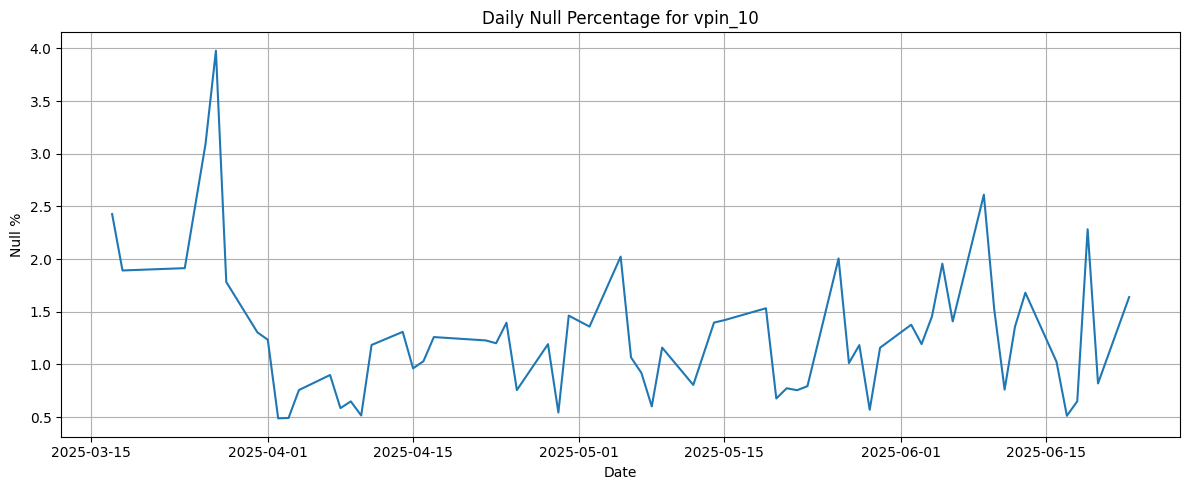

In [142]:

# Replace this with your actual predictor name
predictor = "vpin_10"

# Ensure datetime is parsed correctly
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract date
df['date'] = df['datetime'].dt.date

# Calculate daily null percentage for the predictor
daily_null_pct = df.groupby('date')[predictor].apply(lambda x: x.isnull().mean() * 100)

# Plot
plt.figure(figsize=(12, 5))
daily_null_pct.plot(title=f'Daily Null Percentage for {predictor}')
plt.ylabel('Null %')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()


In [143]:
from decimal import Decimal

# Define a large number to replace infinities
large_number = 1e10

# Replace both positive and negative infinity
df.replace([np.inf, -np.inf], large_number, inplace=True)

df = df.applymap(lambda x: float(x) if isinstance(x, Decimal) else x)

DataFrame.applymap has been deprecated. Use DataFrame.map instead.


In [144]:
df['class_70_4_long']=df['class_70_4'].apply(lambda x: int(x>=1))
df['class_70_4_short']=df['class_70_4'].apply(lambda x: int(x<=-1))

# Longs

In [145]:
#df_long=df[(df['contract']=='dem2')&(df['trd_price'].apply(float)-df['ask_price']>0.0)]
df_long=df[(df['trd_gap']>0.0)]

In [146]:
target_col='class_70_4_long'
target_col2='class_70_4_long'

feature_cols=['delta_a_05',
 'delta_a_10',
 'delta_a_50',
 'delta_a_75',
 'delta_b_05',
 'delta_b_10',
 'delta_b_50',
 'delta_b_75',
 'delta_mid_05',
 'delta_mid_10',
 'delta_mid_50',
 'delta_mid_75',
 'delta_ba_05',
 'delta_ba_10',
 'delta_ba_50',
 'delta_ba_75',
 'ba_volrat_00',
 'ba_volrat_05',
 'ba_volrat_08',
 'ba_volrat_10',
 'ba_volrat_15',
 'ba_volrat_20',
 'ba_volrat_25',
 'diff_am_wm_00',
 'diff_am_wm_05',
 'diff_am_wm_08',
 'diff_am_wm_10',
 'diff_am_wm_15',
 'diff_am_wm_20',
 'diff_am_wm_25',
 'delta_mw_00_05',
 'delta_mw_05_05',
 'delta_mw_08_05',
 'delta_mw_10_05',
 'delta_mw_15_05',
 'delta_mw_20_05',
 'delta_mw_25_05',
 'delta_mw_00_10',
 'delta_mw_05_10',
 'delta_mw_08_10',
 'delta_mw_10_10',
 'delta_mw_15_10',
 'delta_mw_20_10',
 'delta_mw_25_10',
 'delta_mw_00_50',
 'delta_mw_05_50',
 'delta_mw_08_50',
 'delta_mw_10_50',
 'delta_mw_15_50',
 'delta_mw_20_50',
 'delta_mw_25_50',
 'delta_mw_00_75',
 'delta_mw_05_75',
 'delta_mw_08_75',
 'delta_mw_10_75',
 'delta_mw_15_75',
 'delta_mw_20_75',
 'delta_mw_25_75',
 'b_price_sparsity',
 'a_price_sparsity',
 'ba_spread',
 'diff_ema_am_wm_00',
 'diff_ema_am_wm_05',
 'diff_ema_am_wm_08',
 'diff_ema_am_wm_10',
 'diff_ema_am_wm_15',
 'diff_ema_am_wm_20',
 'diff_ema_am_wm_25',
 'diff_ema_ba_mba',
 'lamb_tr_b_05',
 'lamb_tr_a_05',
 'lamb_tr_b_10',
 'lamb_tr_a_10',
 'lamb_tr_b_50',
 'lamb_tr_a_50',
 'lamb_tr_b_75',
 'lamb_tr_a_75',
 'ilamb_b_10',
 'ilamb_a_10',
 'ilamb_b_50',
 'ilamb_a_50',
 'ilamb_b_75',
 'ilamb_a_75',
 'dlamb_b_75',
 'dlamb_a_75',
 'trd_momentum_10',
 'trd_momentum_acc_10',
 'trd_momentum_50',
 'trd_momentum_acc_50',
 'trd_momentum_100',
 'trd_momentum_acc_100',
 'ret',
 'vpin_10',
 'vpin_20',
 'vpin_50',
 'vpin_100',
 'trd_gap']

In [147]:
df_long=df_long.dropna(subset=feature_cols+[target_col])

In [148]:
df_long[target_col].value_counts()

class_70_4_long
1    1860
0    1199
Name: count, dtype: int64

In [149]:
df_long[target_col].value_counts(normalize=True)

class_70_4_long
1    0.608042
0    0.391958
Name: proportion, dtype: float64

## Univariate predictor analysis

In [150]:
result = []
for feat in feature_cols:
    try:
        #print(feat)
        gini = mofr.metrics.gini(df_long[target_col].apply(float), df_long[feat].apply(float))
        result.append((feat, gini))
    except:
        print('problem')

pd.DataFrame(result, columns=["feature", "gini"]).sort_values(by="gini", key=lambda x: x.abs(), ascending=False)

,feature,gini
96,trd_gap,0.161311
77,ilamb_b_10,-0.078939
85,trd_momentum_10,0.078420
13,delta_ba_10,0.072120
69,lamb_tr_b_05,-0.071910
70,lamb_tr_a_05,0.071910
28,diff_am_wm_20,0.071143
82,ilamb_a_75,0.060107
79,ilamb_b_50,-0.057950
78,ilamb_a_10,0.055668


## XGB model

In [151]:
# --- Month-based XGBoost model training and evaluation for LONGS ---
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import calendar

# Prepare date column
if 'date' not in df_long.columns:
    df_long['date'] = df_long['datetime'].dt.date
if 'month' not in df_long.columns:
    df_long['month'] = pd.to_datetime(df_long['date']).dt.to_period('M')

unique_months = sorted(df_long['month'].unique())

all_predictions = []
all_actual_values = []
all_probabilities = []
all_dates = []

for i, month in enumerate(unique_months):
    # Use all data before the current month for training
    train_months = unique_months[:i]
    if len(train_months) == 0:
        continue
    train_mask = df_long['month'].isin(train_months)
    test_mask = df_long['month'] == month
    X_train = df_long.loc[train_mask, feature_cols]
    y_train = df_long.loc[train_mask, target_col]
    X_test = df_long.loc[test_mask, feature_cols]
    y_test = df_long.loc[test_mask, target_col]
    test_dates = df_long.loc[test_mask, 'date']
    if len(X_test) == 0 or len(X_train) == 0:
        continue
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1
    model = XGBClassifier(
        n_estimators=10,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    all_predictions.extend(y_pred)
    all_actual_values.extend(y_test)
    all_probabilities.extend(y_pred_proba)
    all_dates.extend(list(test_dates))

results_df_long = pd.DataFrame({
    'date': all_dates,
    'actual': all_actual_values,
    'predicted': all_predictions,
    'probability': all_probabilities
})

results_df_long['month'] = pd.to_datetime(results_df_long['date']).dt.month
monthly_metrics = []
for month in sorted(results_df_long['month'].unique()):
    month_mask = results_df_long['month'] == month
    month_data = results_df_long[month_mask]
    lift = mofr.metrics.lift(month_data['actual'], month_data['probability'])
    gini = mofr.metrics.gini(month_data['actual'].apply(int), month_data['probability'])
    sorted_data = month_data.sort_values('probability', ascending=False)
    top_50 = sorted_data.head(50)
    precision_top_50 = top_50['actual'].mean() if len(top_50) == 50 else None
    monthly_metrics.append({
        'month': month,
        'lift': lift,
        'gini': gini,
        'precision_top_50': precision_top_50
    })
metrics_df_long = pd.DataFrame(monthly_metrics)
print('Monthly Performance Metrics (Longs):')
display(metrics_df_long)

print('\nOverall Performance Metrics (Longs):')
if len(results_df_long) == 0:
    print('No predictions available for overall metrics.')
else:
    print('Lift:', mofr.metrics.lift(results_df_long['actual'], results_df_long['probability']))
    print('Gini:', mofr.metrics.gini(results_df_long['actual'].apply(int), results_df_long['probability']))
    sorted_overall = results_df_long.sort_values('probability', ascending=False)
    top_50_overall = sorted_overall.head(50)
    precision_top_50_overall = top_50_overall['actual'].mean() if len(top_50_overall) == 50 else None
    print(f'Precision (top 50): {precision_top_50_overall:.4f}' if precision_top_50_overall is not None else "N/A")

Monthly Performance Metrics (Longs):


,month,lift,gini,precision_top_50
0,4,0.876086,-0.017919,0.42
1,5,1.180568,0.103880,0.78
2,6,1.111205,0.030704,0.74



Overall Performance Metrics (Longs):
Lift: 1.0883256528417817
Gini: 0.029424571697178825
Precision (top 50): 0.4200


# Shorts

In [152]:
#df_short=df[(df['contract']=='dem2')&(df['bid_price']-df['trd_price'].apply(float)>0.0)]
df_short=df[(df['trd_gap']<0.0)]

In [153]:
target_col='class_70_4_short'

feature_cols=['delta_a_05',
 'delta_a_10',
 'delta_a_50',
 'delta_a_75',
 'delta_b_05',
 'delta_b_10',
 'delta_b_50',
 'delta_b_75',
 'delta_mid_05',
 'delta_mid_10',
 'delta_mid_50',
 'delta_mid_75',
 'delta_ba_05',
 'delta_ba_10',
 'delta_ba_50',
 'delta_ba_75',
 'ba_volrat_00',
 'ba_volrat_05',
 'ba_volrat_08',
 'ba_volrat_10',
 'ba_volrat_15',
 'ba_volrat_20',
 'ba_volrat_25',
 'diff_am_wm_00',
 'diff_am_wm_05',
 'diff_am_wm_08',
 'diff_am_wm_10',
 'diff_am_wm_15',
 'diff_am_wm_20',
 'diff_am_wm_25',
 'delta_mw_00_05',
 'delta_mw_05_05',
 'delta_mw_08_05',
 'delta_mw_10_05',
 'delta_mw_15_05',
 'delta_mw_20_05',
 'delta_mw_25_05',
 'delta_mw_00_10',
 'delta_mw_05_10',
 'delta_mw_08_10',
 'delta_mw_10_10',
 'delta_mw_15_10',
 'delta_mw_20_10',
 'delta_mw_25_10',
 'delta_mw_00_50',
 'delta_mw_05_50',
 'delta_mw_08_50',
 'delta_mw_10_50',
 'delta_mw_15_50',
 'delta_mw_20_50',
 'delta_mw_25_50',
 'delta_mw_00_75',
 'delta_mw_05_75',
 'delta_mw_08_75',
 'delta_mw_10_75',
 'delta_mw_15_75',
 'delta_mw_20_75',
 'delta_mw_25_75',
 'b_price_sparsity',
 'a_price_sparsity',
 'ba_spread',
 'diff_ema_am_wm_00',
 'diff_ema_am_wm_05',
 'diff_ema_am_wm_08',
 'diff_ema_am_wm_10',
 'diff_ema_am_wm_15',
 'diff_ema_am_wm_20',
 'diff_ema_am_wm_25',
 'diff_ema_ba_mba',
 'lamb_tr_b_05',
 'lamb_tr_a_05',
 'lamb_tr_b_10',
 'lamb_tr_a_10',
 'lamb_tr_b_50',
 'lamb_tr_a_50',
 'lamb_tr_b_75',
 'lamb_tr_a_75',
 'ilamb_b_10',
 'ilamb_a_10',
 'ilamb_b_50',
 'ilamb_a_50',
 'ilamb_b_75',
 'ilamb_a_75',
 'dlamb_b_75',
 'dlamb_a_75',
 'trd_momentum_10',
 'trd_momentum_acc_10',
 'trd_momentum_50',
 'trd_momentum_acc_50',
 'trd_momentum_100',
 'trd_momentum_acc_100',
 'ret',
 'vpin_10',
 'vpin_20',
 'vpin_50',
 'vpin_100',
 'trd_gap']

In [154]:
df_short=df_short.dropna(subset=feature_cols+[target_col])

In [155]:
df_short[target_col].value_counts()

class_70_4_short
1    1863
0    1164
Name: count, dtype: int64

In [156]:
df_short[target_col].value_counts(normalize=True)

class_70_4_short
1    0.615461
0    0.384539
Name: proportion, dtype: float64

## Univariate predictor analysis

In [157]:
result = []
for feat in feature_cols:
    try:
        #print(feat)
        gini = mofr.metrics.gini(df_short[target_col].apply(float), df_short[feat].apply(float))
        result.append((feat, gini))
    except:
        print('problem')

pd.DataFrame(result, columns=["feature", "gini"]).sort_values(by="gini", key=lambda x: x.abs(), ascending=False)

,feature,gini
96,trd_gap,-0.163511
22,ba_volrat_25,-0.089934
86,trd_momentum_acc_10,-0.086866
8,delta_mid_05,-0.080801
0,delta_a_05,-0.080531
30,delta_mw_00_05,-0.080136
92,vpin_10,0.079814
85,trd_momentum_10,-0.079246
21,ba_volrat_20,-0.079026
31,delta_mw_05_05,-0.076219


## Month-based Logistic Regression Model (Shorts)
This cell implements the month-based model training and evaluation for the shorts strategy. The model is trained on all available data up to the end of each month and used to predict for the following month. Metrics include precision@100, lift, gini, and accuracy, both monthly and overall.

In [158]:
# --- Month-based XGBoost model training and evaluation for SHORTS ---
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import calendar

if 'date' not in df_short.columns:
    df_short['date'] = df_short['datetime'].dt.date
if 'month' not in df_short.columns:
    df_short['month'] = pd.to_datetime(df_short['date']).dt.to_period('M')

unique_months = sorted(df_short['month'].unique())

all_predictions = []
all_actual_values = []
all_probabilities = []
all_dates = []

for i, month in enumerate(unique_months):
    train_months = unique_months[:i]
    if len(train_months) == 0:
        continue
    train_mask = df_short['month'].isin(train_months)
    test_mask = df_short['month'] == month
    X_train = df_short.loc[train_mask, feature_cols]
    y_train = df_short.loc[train_mask, target_col]
    X_test = df_short.loc[test_mask, feature_cols]
    y_test = df_short.loc[test_mask, target_col]
    test_dates = df_short.loc[test_mask, 'date']
    if len(X_test) == 0 or len(X_train) == 0:
        continue
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1
    model = XGBClassifier(
        n_estimators=10,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    all_predictions.extend(y_pred)
    all_actual_values.extend(y_test)
    all_probabilities.extend(y_pred_proba)
    all_dates.extend(list(test_dates))

results_df_short = pd.DataFrame({
    'date': all_dates,
    'actual': all_actual_values,
    'predicted': all_predictions,
    'probability': all_probabilities
})

results_df_short['month'] = pd.to_datetime(results_df_short['date']).dt.month
monthly_metrics = []
for month in sorted(results_df_short['month'].unique()):
    month_mask = results_df_short['month'] == month
    month_data = results_df_short[month_mask]
    lift = mofr.metrics.lift(month_data['actual'], month_data['probability'])
    gini = mofr.metrics.gini(month_data['actual'].apply(int), month_data['probability'])
    sorted_data = month_data.sort_values('probability', ascending=False)
    top_50 = sorted_data.head(50)
    precision_top_50 = top_50['actual'].mean() if len(top_50) == 50 else None
    monthly_metrics.append({
        'month': month,
        'lift': lift,
        'gini': gini,
        'precision_top_50': precision_top_50
    })
metrics_df_short = pd.DataFrame(monthly_metrics)
print('Monthly Performance Metrics (Shorts):')
display(metrics_df_short)

print('\nOverall Performance Metrics (Shorts):')
if len(results_df_short) == 0:
    print('No predictions available for overall metrics (Shorts).')
else:
    print('Lift:', mofr.metrics.lift(results_df_short['actual'], results_df_short['probability']))
    print('Gini:', mofr.metrics.gini(results_df_short['actual'].apply(int), results_df_short['probability']))
    sorted_overall = results_df_short.sort_values('probability', ascending=False)
    top_50_overall = sorted_overall.head(50)
    precision_top_50_overall = top_50_overall['actual'].mean() if len(top_50_overall) == 50 else None
    print(f'Precision (top 50): {precision_top_50_overall:.4f}' if precision_top_50_overall is not None else "N/A")

Monthly Performance Metrics (Shorts):


,month,lift,gini,precision_top_50
0,4,0.992813,0.003085,0.64
1,5,0.975137,0.012918,0.72
2,6,1.206030,0.151958,0.66



Overall Performance Metrics (Shorts):
Lift: 1.0582071223905034
Gini: 0.037828268560743616
Precision (top 50): 0.6400


Training long model...


[09:57:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

[09:57:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

Overall accuracy (long): 0.4959

Training short model...


[09:57:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

[09:57:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[09:57:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

Overall accuracy (short): 0.5041


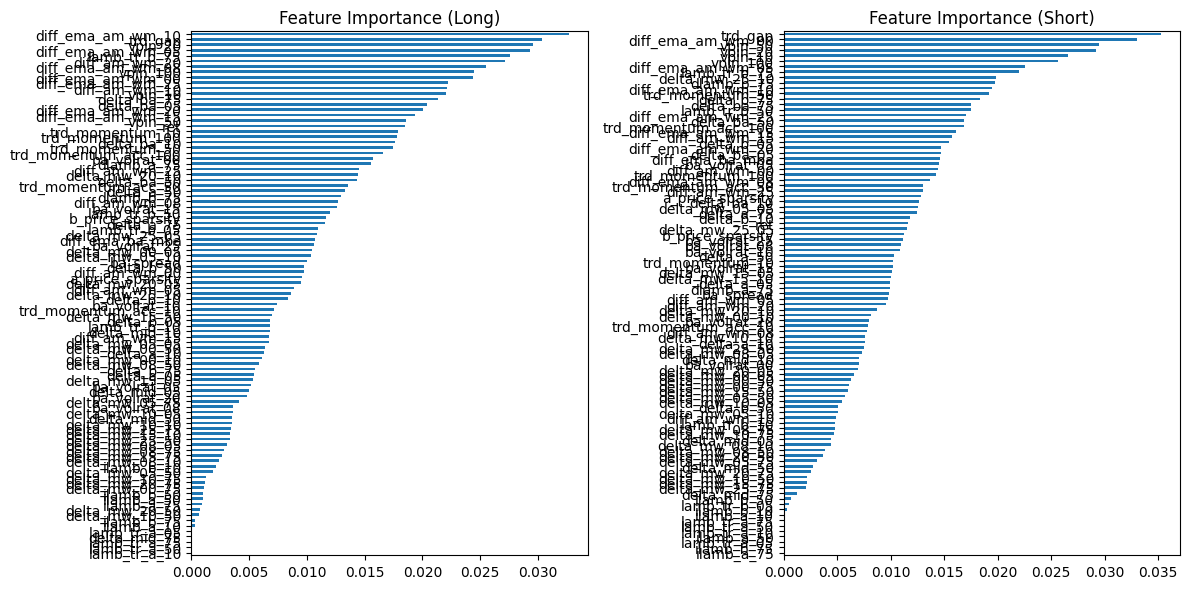

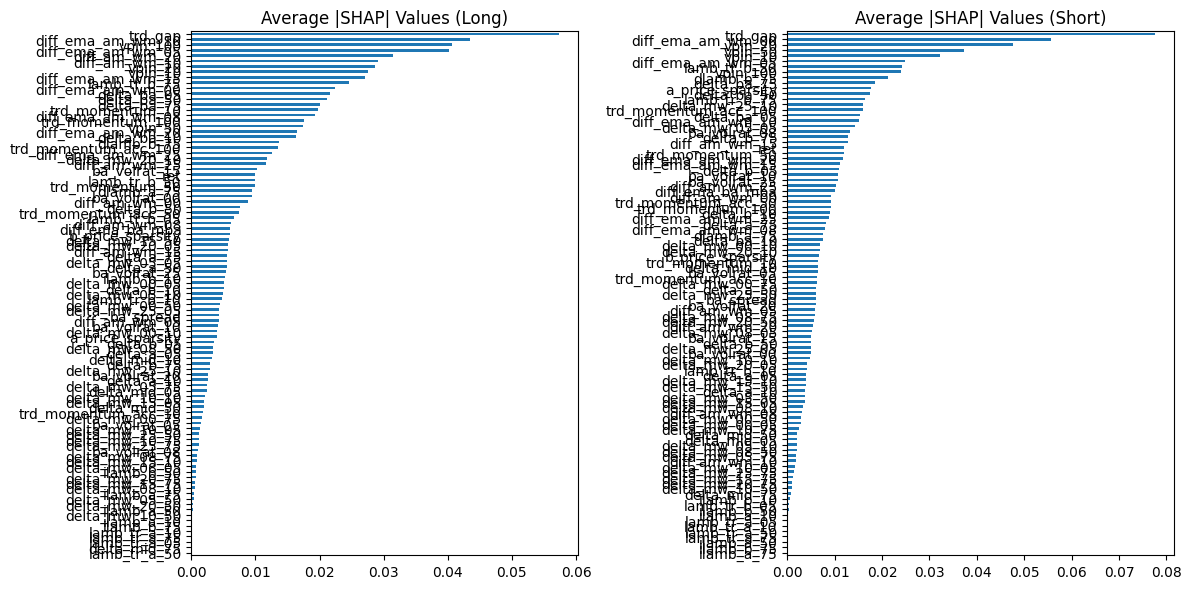


Top 5 Most Important Features (Long):
diff_ema_am_wm_10    0.032670
trd_gap              0.030328
vpin_20              0.029595
diff_ema_am_wm_05    0.029320
lamb_tr_b_75         0.027636
dtype: float32

Top 5 Most Important Features (Short):
trd_gap              0.035280
diff_ema_am_wm_00    0.033053
vpin_50              0.029424
vpin_20              0.029207
vpin_10              0.026569
dtype: float32


In [159]:
from sklearn.preprocessing import StandardScaler
import shap
import numpy as np
import calendar
import xgboost as xgb
from xgboost import XGBClassifier

# Initialize for both long and short models
df_long['date'] = df_long['datetime'].dt.date
df_short['date'] = df_short['datetime'].dt.date

def train_and_evaluate_model(df, feature_cols, target_col, window_days=14):
    unique_dates = sorted(df['date'].unique())
    all_predictions = []
    all_actual_values = []
    all_probabilities = []
    all_dates = []
    feature_importance_list = []
    shap_values_list = []
    
    # For each date after the initial window
    for i in range(window_days, len(unique_dates)):
        current_date = unique_dates[i]
        
        # Get training data from the rolling window
        train_dates = unique_dates[i-window_days:i]
        train_mask = df['date'].isin(train_dates)
        test_mask = (df['date'] == current_date)
        
        X_train = df.loc[train_mask, feature_cols]
        y_train = df.loc[train_mask, target_col]
        X_test = df.loc[test_mask, feature_cols]
        y_test = df.loc[test_mask, target_col]
        
        # Skip if no test data for this date
        if len(X_test) == 0:
            continue
            
        # Train XGBoost model
        model = XGBClassifier(
            max_depth=3,
            learning_rate=0.1,
            n_estimators=10,
            scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # Handle class imbalance
            random_state=42
        )
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)
        
        # Store feature importance for this window
        feature_importance_list.append(
            pd.Series(model.feature_importances_, index=feature_cols)
        )
        
        # Calculate SHAP values for feature importance
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):  # For binary classification
            shap_values = shap_values[1]  # Take positive class
        shap_values_list.append(pd.DataFrame(shap_values, columns=feature_cols))
        
        # Store results
        all_predictions.extend(y_pred)
        all_actual_values.extend(y_test)
        all_probabilities.extend(y_pred_proba)
        all_dates.extend([current_date] * len(y_pred))
    
    # Calculate average feature importance across all windows
    avg_feature_importance = pd.concat(feature_importance_list, axis=1).mean(axis=1)
    avg_shap_values = pd.concat(shap_values_list).abs().mean()
    
    return pd.DataFrame({
        'date': all_dates,
        'actual': all_actual_values,
        'predicted': all_predictions,
        'probability': all_probabilities
    }), avg_feature_importance, avg_shap_values

# Train and evaluate long model
print("Training long model...")
results_long, importance_long, shap_long = train_and_evaluate_model(
    df_long, feature_cols, 'class_70_4_long'
)
print(f"Overall accuracy (long): {accuracy_score(results_long['actual'], results_long['predicted']):.4f}")

# Train and evaluate short model
print("\nTraining short model...")
results_short, importance_short, shap_short = train_and_evaluate_model(
    df_short, feature_cols, 'class_70_4_short'
)
print(f"Overall accuracy (short): {accuracy_score(results_short['actual'], results_short['predicted']):.4f}")

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
importance_long.sort_values().plot(kind='barh')
plt.title('Feature Importance (Long)')
plt.tight_layout()

plt.subplot(1, 2, 2)
importance_short.sort_values().plot(kind='barh')
plt.title('Feature Importance (Short)')
plt.tight_layout()
plt.show()

# Plot SHAP values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
shap_long.sort_values().plot(kind='barh')
plt.title('Average |SHAP| Values (Long)')
plt.tight_layout()

plt.subplot(1, 2, 2)
shap_short.sort_values().plot(kind='barh')
plt.title('Average |SHAP| Values (Short)')
plt.tight_layout()
plt.show()

# Print top 5 most important features for each model
print("\nTop 5 Most Important Features (Long):")
print(importance_long.sort_values(ascending=False).head())
print("\nTop 5 Most Important Features (Short):")
print(importance_short.sort_values(ascending=False).head())